In [1]:
%pip install -q scikit-learn nibabel SimpleITK tensorboard

Note: you may need to restart the kernel to use updated packages.


# Four-Class Brain Tumor Classification
## Glioma, Meningioma, Pituitary, Healthy

This notebook trains a Vision Transformer (ViT) model to classify brain tumors into 4 categories and evaluates per-class accuracy.

## 1. Setup and Imports

In [2]:
import os
import sys
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from tqdm import tqdm

# Add parent directory to path for imports
sys.path.insert(0, os.path.abspath('..'))

from src.model import create_vit_classifier
from src.dataset import BrainTumorDataset, create_dataloaders, get_class_weights
from src.train import Trainer
from src.evaluate import Evaluator
from src.preprocessing import create_data_split, organize_processed_data
from src.utils import set_seed, get_device

# Set random seed
set_seed(42)

# Get device
device = get_device()

print(f" All modules imported successfully!")
print(f" Using device: {device}")

Using GPU: NVIDIA RTX PRO 6000 Blackwell Workstation Edition
 All modules imported successfully!
 Using device: cuda


## 2. Prepare 4-Class Dataset

In [5]:
# Path to 4-class dataset
four_class_dataset = "../Dataset/Extracted data/Brain_Tumor_MRI_Scans"
print("PREPARING 4-CLASS DATASET")

# Check dataset structure
classes = [d for d in os.listdir(four_class_dataset) if os.path.isdir(os.path.join(four_class_dataset, d))]
print(f"\nFound {len(classes)} classes: {', '.join(classes)}")

# Count images per class
class_counts = {}
for class_name in classes:
    class_path = Path(four_class_dataset) / class_name
    num_images = len(list(class_path.glob('*.jpg')) + list(class_path.glob('*.png')))
    class_counts[class_name] = num_images
    print(f"  {class_name}: {num_images} images")

print(f"\nTotal images: {sum(class_counts.values()):,}")

PREPARING 4-CLASS DATASET

Found 4 classes: healthy, glioma, pituitary, meningioma
  healthy: 2000 images
  glioma: 1621 images
  pituitary: 1757 images
  meningioma: 1645 images

Total images: 7,023


In [6]:
# Create train/val/test splits (70/15/15)
print("CREATING TRAIN/VAL/TEST SPLITS")


splits = create_data_split(
    four_class_dataset,
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15,
    random_state=42
)

for split_name, df in splits.items():
    print(f"\n{split_name.upper()} split:")
    print(f"  Total: {len(df)} images")
    class_dist = df['class_name'].value_counts()
    for cls, count in class_dist.items():
        percentage = (count / len(df)) * 100
        print(f"    {cls}: {count} ({percentage:.1f}%)")

CREATING TRAIN/VAL/TEST SPLITS

TRAIN split:
  Total: 4915 images
    healthy: 1400 (28.5%)
    pituitary: 1229 (25.0%)
    meningioma: 1151 (23.4%)
    glioma: 1135 (23.1%)

VAL split:
  Total: 1054 images
    healthy: 300 (28.5%)
    pituitary: 264 (25.0%)
    meningioma: 247 (23.4%)
    glioma: 243 (23.1%)

TEST split:
  Total: 1054 images
    healthy: 300 (28.5%)
    pituitary: 264 (25.0%)
    meningioma: 247 (23.4%)
    glioma: 243 (23.1%)


In [7]:
# Save metadata files
output_dir = Path("../Dataset/four_class_data")
output_dir.mkdir(parents=True, exist_ok=True)

print("SAVING METADATA FILES")
metadata_paths = organize_processed_data(splits, output_dir, copy_files=False)

print("\nMetadata files saved:")
for split_name, path in metadata_paths.items():
    print(f"  {split_name}: {path}")

print("\n Dataset preparation complete!")

SAVING METADATA FILES

Metadata files saved:
  train: ../Dataset/four_class_data/train_metadata.csv
  val: ../Dataset/four_class_data/val_metadata.csv
  test: ../Dataset/four_class_data/test_metadata.csv
  combined: ../Dataset/four_class_data/all_metadata.csv

 Dataset preparation complete!


## 3. Configuration

In [8]:
# Training configuration
CONFIG = {
    # Data
    'train_metadata': '../Dataset/four_class_data/train_metadata.csv',
    'val_metadata': '../Dataset/four_class_data/val_metadata.csv',
    'test_metadata': '../Dataset/four_class_data/test_metadata.csv',
    'batch_size': 16,
    'num_workers': 4,

    # Model
    'image_size': 224,
    'num_classes': 4,  # glioma, healthy, meningioma, pituitary
    'embed_dim': 768,
    'depth': 12,
    'num_heads': 12,
    'dropout': 0.1,

    # Training
    'num_epochs': 50,
    'learning_rate': 1e-4,
    'weight_decay': 0.05,
    'patience': 15,

    # Paths
    'checkpoint_dir': '../experiments/four_class_checkpoints',
    'log_dir': '../experiments/four_class_logs',
    'results_dir': '../experiments/four_class_results'
}

print("=" * 70)
print("CONFIGURATION")
print("=" * 70)
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

CONFIGURATION
  train_metadata: ../Dataset/four_class_data/train_metadata.csv
  val_metadata: ../Dataset/four_class_data/val_metadata.csv
  test_metadata: ../Dataset/four_class_data/test_metadata.csv
  batch_size: 16
  num_workers: 4
  image_size: 224
  num_classes: 4
  embed_dim: 768
  depth: 12
  num_heads: 12
  dropout: 0.1
  num_epochs: 50
  learning_rate: 0.0001
  weight_decay: 0.05
  patience: 15
  checkpoint_dir: ../experiments/four_class_checkpoints
  log_dir: ../experiments/four_class_logs
  results_dir: ../experiments/four_class_results


## 4. Load Data

In [9]:
# Augmentation configuration
augment_config = {
    'rotation': True,
    'flip': True,
    'zoom': True,
    'intensity': True
}

print("CREATING DATA LOADERS")

# Create data loaders
train_loader, val_loader, test_loader, class_names = create_dataloaders(
    train_csv=CONFIG['train_metadata'],
    val_csv=CONFIG['val_metadata'],
    test_csv=CONFIG['test_metadata'],
    batch_size=CONFIG['batch_size'],
    img_size=CONFIG['image_size'],
    num_workers=CONFIG['num_workers'],
    augment_train=True
    # augment_config is not a valid argument for create_dataloaders() in this codebase
    # If you want to customize augmentation, edit the BrainTumorDataset or augmentation pipeline in src/dataset.py
 )

print(f"\nDataset sizes:")
print(f"  Training:   {len(train_loader.dataset):,} samples")
print(f"  Validation: {len(val_loader.dataset):,} samples")
print(f"  Test:       {len(test_loader.dataset):,} samples")

print(f"\nClass names: {class_names}")
print(f"Number of batches per epoch:")
print(f"  Train: {len(train_loader)}")
print(f"  Val:   {len(val_loader)}")
print(f"  Test:  {len(test_loader)}")

CREATING DATA LOADERS

Dataset sizes:
  Training:   4,915 samples
  Validation: 1,054 samples
  Test:       1,054 samples

Class names: ['glioma', 'healthy', 'meningioma', 'pituitary']
Number of batches per epoch:
  Train: 308
  Val:   66
  Test:  66


In [10]:
# Compute class weights for handling any imbalance
print("\n" + "=" * 70)
print("CLASS WEIGHTS")
print("=" * 70)

class_weights = get_class_weights(CONFIG['train_metadata']).to(device)

print("\nClass weights (for loss function):")
for i, (cls, weight) in enumerate(zip(class_names, class_weights)):
    print(f"  {cls}: {weight:.4f}")

print("\nHigher weights = minority class (emphasized during training)")


CLASS WEIGHTS

Class weights (for loss function):
  glioma: 1.0826
  healthy: 0.8777
  meningioma: 1.0675
  pituitary: 0.9998

Higher weights = minority class (emphasized during training)


## 5. Create Model

In [11]:
print("INITIALIZING MODEL")

# Create ViT model
model = create_vit_classifier(
    num_classes=CONFIG['num_classes'],
    img_size=CONFIG['image_size'],
    in_channels=3
).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nModel: Vision Transformer (ViT)")
print(f"  Total parameters:     {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Number of classes:    {CONFIG['num_classes']}")
print(f"  Input size:           {CONFIG['image_size']}x{CONFIG['image_size']}")

INITIALIZING MODEL

Model: Vision Transformer (ViT)
  Total parameters:     85,801,732
  Trainable parameters: 85,801,732
  Number of classes:    4
  Input size:           224x224


In [12]:
# Loss function with class weights
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CONFIG['learning_rate'],
    weight_decay=CONFIG['weight_decay']
)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CONFIG['num_epochs'],
    eta_min=1e-6
)

print("\n Loss function: CrossEntropyLoss (weighted)")
print(" Optimizer: AdamW")
print(" Scheduler: CosineAnnealingLR")


 Loss function: CrossEntropyLoss (weighted)
 Optimizer: AdamW
 Scheduler: CosineAnnealingLR


## 6. Train Model

In [13]:
print("TRAINING 4-CLASS MODEL")

# Create trainer
trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    save_dir=CONFIG['checkpoint_dir'],
    log_dir=CONFIG['log_dir'],
    num_classes=CONFIG['num_classes']
)

# Train the model
print("\nStarting training...\n")
trainer.train(
    num_epochs=CONFIG['num_epochs'],
    early_stopping_patience=CONFIG['patience']
)

TRAINING 4-CLASS MODEL

Starting training...

Starting training for 50 epochs...
Device: cuda
Model parameters: 85,801,732


Epoch 1 [Val]: 100%|██████████| 66/66 [00:01<00:00, 34.53it/s, loss=1.65] 



Epoch 1/50 (18.0s)
  Train - Loss: 1.4218, Acc: 0.3168
  Val   - Loss: 1.4154, Acc: 0.3615
  Val   - P: 0.1823, R: 0.3615, F1: 0.2317
  New best model saved! (Val Acc: 0.3615)
----------------------------------------------------------------------


Epoch 2 [Val]: 100%|██████████| 66/66 [00:01<00:00, 53.80it/s, loss=1.4]  



Epoch 2/50 (15.1s)
  Train - Loss: 1.3043, Acc: 0.3862
  Val   - Loss: 1.2417, Acc: 0.4488
  Val   - P: 0.5917, R: 0.4488, F1: 0.3637
  New best model saved! (Val Acc: 0.4488)
----------------------------------------------------------------------


...


Epoch 48/50 (15.9s)
  Train - Loss: 0.3191, Acc: 0.8808
  Val   - Loss: 0.3634, Acc: 0.8843
  Val   - P: 0.8834, R: 0.8843, F1: 0.8819
----------------------------------------------------------------------


Epoch 49 [Val]: 100%|██████████| 66/66 [00:01<00:00, 53.15it/s, loss=0.669] 



Epoch 49/50 (15.9s)
  Train - Loss: 0.3177, Acc: 0.8800
  Val   - Loss: 0.3561, Acc: 0.8824
  Val   - P: 0.8819, R: 0.8824, F1: 0.8813
----------------------------------------------------------------------


Epoch 50 [Val]: 100%|██████████| 66/66 [00:01<00:00, 53.62it/s, loss=0.654] 


Epoch 50/50 (15.9s)
  Train - Loss: 0.3251, Acc: 0.8773
  Val   - Loss: 0.3532, Acc: 0.8833
  Val   - P: 0.8824, R: 0.8833, F1: 0.8822
----------------------------------------------------------------------

Training completed!
Best validation accuracy: 0.8861


## 7. Evaluate Model

In [14]:
print("EVALUATING 4-CLASS MODEL")
print("=" * 70)

# Load best model
best_model_path = Path(CONFIG['checkpoint_dir']) / 'best_model.pth'
checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])

print(f"\n Loaded best model from epoch {checkpoint['epoch']}")
print(f"  Best validation accuracy: {checkpoint['best_val_acc']:.4f}")

# Create evaluator
evaluator = Evaluator(model, device=device)

# Evaluate on test set
print("\n" + "-" * 70)
print("TEST SET EVALUATION")
print("-" * 70)

test_metrics = evaluator.evaluate(test_loader, class_names=class_names)

# Print overall metrics
evaluator.print_metrics(test_metrics, class_names=class_names)

EVALUATING 4-CLASS MODEL

 Loaded best model from epoch 47
  Best validation accuracy: 0.8861

----------------------------------------------------------------------
TEST SET EVALUATION
----------------------------------------------------------------------


Evaluating: 100%|██████████| 66/66 [00:01<00:00, 35.18it/s]

EVALUATION METRICS

Overall Metrics:
  Accuracy:           0.8918
  Precision (macro):  0.8877
  Recall (macro):     0.8869
  F1-Score (macro):   0.8860
  ROC-AUC (OVR):      0.9800

Per-Class Metrics:

  glioma:
    Precision: 0.8765
    Recall:    0.9053
    F1-Score:  0.8907

  healthy:
    Precision: 0.9638
    Recall:    0.9767
    F1-Score:  0.9702

  meningioma:
    Precision: 0.8519
    Recall:    0.7449
    F1-Score:  0.7948

  pituitary:
    Precision: 0.8587
    Recall:    0.9205
    F1-Score:  0.8885



## 8. Per-Class Accuracy Breakdown

In [15]:
print("\n" + "=" * 70)
print("PER-CLASS ACCURACY BREAKDOWN")
print("=" * 70)

# Extract per-class metrics
per_class_results = []
for i, class_name in enumerate(class_names):
    precision = test_metrics[f'precision_{class_name}']
    recall = test_metrics[f'recall_{class_name}']
    f1 = test_metrics[f'f1_{class_name}']

    per_class_results.append({
        'Class': class_name,
        'Precision': precision,
        'Recall (Accuracy)': recall,
        'F1-Score': f1
    })

    print(f"\n{class_name.upper()}:")
    print(f"  Precision:  {precision:.4f} ({precision*100:.2f}%)")
    print(f"  Recall:     {recall:.4f} ({recall*100:.2f}%)")
    print(f"  F1-Score:   {f1:.4f} ({f1*100:.2f}%)")

# Create DataFrame
results_df = pd.DataFrame(per_class_results)

print("\n" + "=" * 70)
print("SUMMARY TABLE")
print("=" * 70)
print(results_df.to_string(index=False))
print(f"\nOverall Accuracy: {test_metrics['accuracy']:.4f} ({test_metrics['accuracy']*100:.2f}%)")


PER-CLASS ACCURACY BREAKDOWN

GLIOMA:
  Precision:  0.8765 (87.65%)
  Recall:     0.9053 (90.53%)
  F1-Score:   0.8907 (89.07%)

HEALTHY:
  Precision:  0.9638 (96.38%)
  Recall:     0.9767 (97.67%)
  F1-Score:   0.9702 (97.02%)

MENINGIOMA:
  Precision:  0.8519 (85.19%)
  Recall:     0.7449 (74.49%)
  F1-Score:   0.7948 (79.48%)

PITUITARY:
  Precision:  0.8587 (85.87%)
  Recall:     0.9205 (92.05%)
  F1-Score:   0.8885 (88.85%)

SUMMARY TABLE
     Class  Precision  Recall (Accuracy)  F1-Score
    glioma   0.876494           0.905350  0.890688
   healthy   0.963816           0.976667  0.970199
meningioma   0.851852           0.744939  0.794816
 pituitary   0.858657           0.920455  0.888483

Overall Accuracy: 0.8918 (89.18%)


## 9. Visualize Results

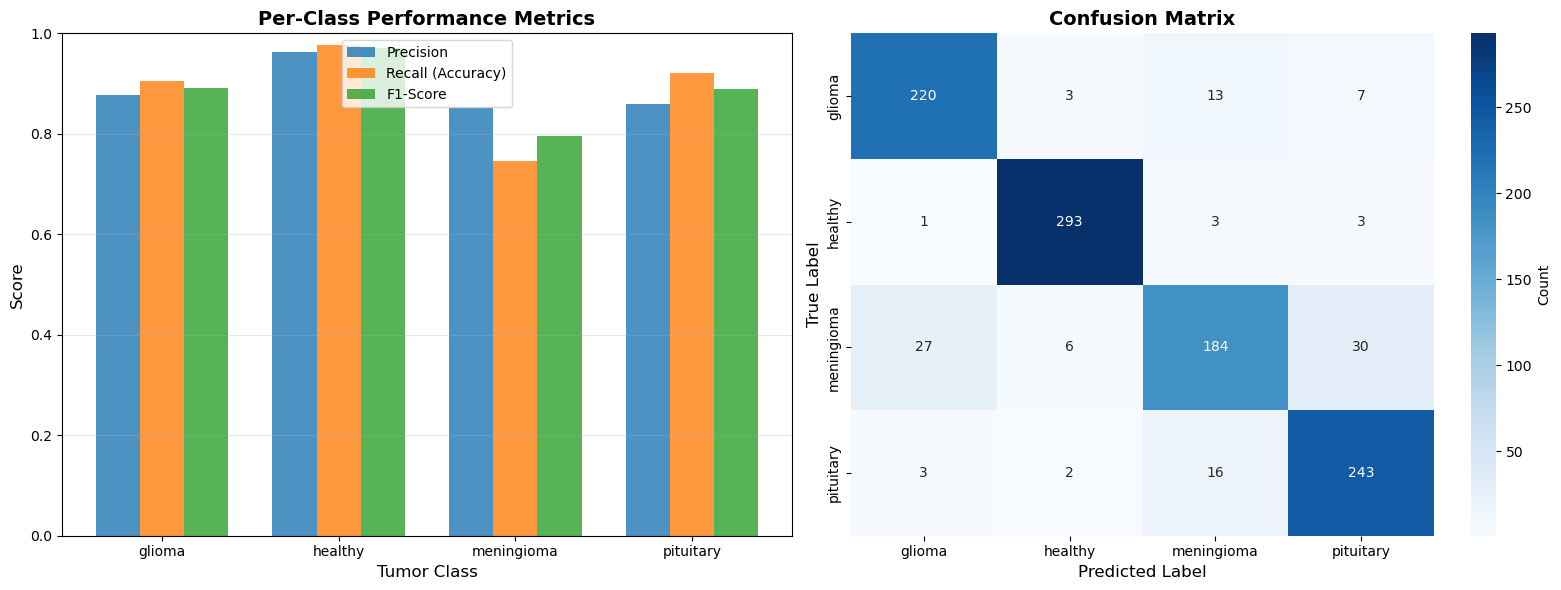


 Visualization saved to: ../experiments/four_class_results/per_class_accuracy.png


In [16]:
# Create results directory
results_dir = Path(CONFIG['results_dir'])
results_dir.mkdir(parents=True, exist_ok=True)

# Visualize per-class metrics
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of per-class metrics
x = np.arange(len(class_names))
width = 0.25

precisions = [results_df.iloc[i]['Precision'] for i in range(len(class_names))]
recalls = [results_df.iloc[i]['Recall (Accuracy)'] for i in range(len(class_names))]
f1s = [results_df.iloc[i]['F1-Score'] for i in range(len(class_names))]

axes[0].bar(x - width, precisions, width, label='Precision', alpha=0.8)
axes[0].bar(x, recalls, width, label='Recall (Accuracy)', alpha=0.8)
axes[0].bar(x + width, f1s, width, label='F1-Score', alpha=0.8)

axes[0].set_xlabel('Tumor Class', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Per-Class Performance Metrics', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(class_names, rotation=0)
axes[0].legend()
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', alpha=0.3)

# Confusion matrix
cm = np.array(test_metrics['confusion_matrix'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1],
            cbar_kws={'label': 'Count'})
axes[1].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.savefig(results_dir / 'per_class_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Visualization saved to: {results_dir / 'per_class_accuracy.png'}")

In [17]:
# Save test metrics to JSON
print("SAVING RESULTS")

# Convert numpy arrays to lists for JSON serialization
metrics_to_save = {}
for k, v in test_metrics.items():
    if isinstance(v, np.ndarray):
        metrics_to_save[k] = v.tolist()
    elif isinstance(v, (np.float32, np.float64)):
        metrics_to_save[k] = float(v)
    else:
        metrics_to_save[k] = v

# Save metrics
with open(results_dir / 'test_metrics_4class.json', 'w') as f:
    json.dump(metrics_to_save, f, indent=2)

# Save per-class summary
results_df.to_csv(results_dir / 'per_class_summary.csv', index=False)

print(f"\n Test metrics saved to: {results_dir / 'test_metrics_4class.json'}")
print(f"\n Per-class summary saved to: {results_dir / 'per_class_summary.csv'}")
print("TRAINING AND EVALUATION COMPLETE!")


SAVING RESULTS

 Test metrics saved to: ../experiments/four_class_results/test_metrics_4class.json

 Per-class summary saved to: ../experiments/four_class_results/per_class_summary.csv
TRAINING AND EVALUATION COMPLETE!
